# Phase 2: Rainfall Data Integration
---
**Purpose:** Transform daily rainfall observations into weekly aggregates and merge with weekly dengue data on the composite key (MOH, Year, Week).  
**Input:** `phase1_output_dengue_data.csv`, `Rainfall_data.xls`  
**Output:** `phase2_output_dengue_rainfall.csv`


## 2.1 Setup

In [1]:
!pip install -q openpyxl xlrd pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

## 2.2 Upload Input Files

In [2]:
print('Upload both files: phase1_output_dengue_data.csv and Rainfall_data.xls')
uploaded = files.upload()

DENGUE_FILE = [f for f in uploaded if 'dengue' in f.lower()][0]
RAINFALL_FILE = [f for f in uploaded if 'rainfall' in f.lower()][0]
print(f'Dengue file: {DENGUE_FILE}')
print(f'Rainfall file: {RAINFALL_FILE}')

Upload both files: phase1_output_dengue_data.csv and Rainfall_data.xls


Saving phase1_output_dengue_data (13).csv to phase1_output_dengue_data (13).csv
Saving Rainfall_data.xls to Rainfall_data.xls
Dengue file: phase1_output_dengue_data (13).csv
Rainfall file: Rainfall_data.xls


## 2.3 Load Dengue Data

In [3]:
dengue_df = pd.read_csv(DENGUE_FILE)
print(f'Dengue records: {len(dengue_df):,}')
print(f'MOH areas: {sorted(dengue_df["MOH"].unique())}')
print(f'Years: {sorted(dengue_df["Year"].unique())}')

Dengue records: 520
MOH areas: ['Balangoda', 'Udawalawa']
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 2.4 Load and Prepare Rainfall Data

In [4]:
# Load rainfall in wide format (132 rows × 34 columns)
rainfall_raw = pd.read_excel(RAINFALL_FILE)
print(f'Raw rainfall: {len(rainfall_raw):,} rows × {len(rainfall_raw.columns)} columns')

# Map meteorological stations to MOH areas
STATION_MOH_MAP = {
    'BALANGODA POST OFFICE': 'Balangoda', 'Balangoda': 'Balangoda', 'BALANGODA': 'Balangoda',
    'UDAWALAWE': 'Udawalawa', 'Udawalawe': 'Udawalawa', 'UDAWALAWA': 'Udawalawa',
    'Uda Walawe': 'Udawalawa', 'UDA WALAWE': 'Udawalawa'
}
rainfall_raw['MOH'] = rainfall_raw['station_name'].map(STATION_MOH_MAP)

unmapped = rainfall_raw[rainfall_raw['MOH'].isna()]['station_name'].unique()
if len(unmapped) > 0:
    print(f'Unmapped stations removed: {unmapped.tolist()}')
    rainfall_raw = rainfall_raw[rainfall_raw['MOH'].notna()].copy()

day_columns = [str(i) for i in range(1, 32) if str(i) in rainfall_raw.columns]
print(f'Day columns: {len(day_columns)} (expected 31)')

Raw rainfall: 132 rows × 34 columns
Day columns: 31 (expected 31)


In [5]:
rainfall_raw.head()

,station_name,Year,Month,1,2,3,4,5,6,7,...,23,24,25,26,27,28,29,30,31,MOH
0,BALANGODA POST OFFICE,2020,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Balangoda
1,BALANGODA POST OFFICE,2020,2,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,Balangoda
2,BALANGODA POST OFFICE,2020,3,0.0,0.0,7.0,0.0,0.0,7.8,0.0,...,0.0,7.0,0.0,0.0,7.8,0.0,0.0,0.0,0.0,Balangoda
3,BALANGODA POST OFFICE,2020,4,0.0,0.0,6.5,0.0,0.0,10.2,65.1,...,0.0,5.0,5.1,5.1,5.1,0.0,0.0,0.0,NaN,Balangoda
4,BALANGODA POST OFFICE,2020,5,0.0,0.0,0.0,23.5,4.8,27.1,0.0,...,0.0,0.0,0.0,1.6,0.0,3.0,0.0,0.0,0.0,Balangoda


## 2.5 Reshape to Long Format with Date Validation

In [6]:
# WIDE-TO-LONG TRANSFORMATION + DATE VALIDATION

print("Starting Rainfall Data Transformation")

# Wide to long format
rainfall_long = pd.melt(
    rainfall_raw,
    id_vars=['station_name', 'MOH', 'Year', 'Month'],
    value_vars=day_columns,
    var_name='Day',
    value_name='Rainfall_mm'
)

rainfall_long['Day'] = rainfall_long['Day'].astype(int)
print(f"Converted to long format: {len(rainfall_long):,} daily observations")

# Validate dates using calendar.monthrange (handles Feb 29, short months, etc.)
def make_valid_date(row):
    try:
        max_day = calendar.monthrange(int(row['Year']), int(row['Month']))[1]
        if int(row['Day']) > max_day or int(row['Day']) < 1:
            return pd.NaT
        return pd.Timestamp(year=int(row['Year']), month=int(row['Month']), day=int(row['Day']))
    except Exception:
        return pd.NaT

rainfall_long['Date'] = rainfall_long.apply(make_valid_date, axis=1)

# Drop invalid dates
invalid_dates = rainfall_long['Date'].isna().sum()
rainfall_long = rainfall_long.dropna(subset=['Date'])
print(f"Removed {invalid_dates} invalid date entries (e.g., 31st February)")

# Clean rainfall values
rainfall_long['Rainfall_mm'] = pd.to_numeric(rainfall_long['Rainfall_mm'], errors='coerce')
missing_rain = rainfall_long['Rainfall_mm'].isna().sum()
rainfall_long = rainfall_long.dropna(subset=['Rainfall_mm'])
print(f"Removed {missing_rain} rows with non-numeric or missing rainfall values")

# Derive epidemiological week (ISO week)
rainfall_long['Week'] = rainfall_long['Date'].dt.isocalendar().week.astype(int)
rainfall_long['Year'] = rainfall_long['Date'].dt.year   # Update Year from actual date if needed

print(f"Final valid daily records: {len(rainfall_long):,}")
print(f"Date range: {rainfall_long['Date'].min().date()} to {rainfall_long['Date'].max().date()}")

Starting Rainfall Data Transformation
Converted to long format: 4,092 daily observations
Removed 73 invalid date entries (e.g., 31st February)
Removed 0 rows with non-numeric or missing rainfall values
Final valid daily records: 4,019
Date range: 2020-01-01 to 2025-08-31


## 2.6 Aggregate to Weekly Measures

In [7]:
# Weekly aggregation: mean daily rainfall, rainy-day count, maximum daily rainfall
# NOTE: `Weekly_Mean_Rainfall` = arithmetic mean of daily rainfall within the week.
weekly_rainfall = rainfall_long.groupby(['MOH', 'Year', 'Week']).agg(
    Weekly_Mean_Rainfall=('Rainfall_mm', 'mean'),
    Rainy_Days=('Rainfall_mm', lambda x: (x > 0).sum()),
    Max_Daily_Rainfall=('Rainfall_mm', 'max')
).reset_index()

print(f'Weekly rainfall records: {len(weekly_rainfall):,}')
print('\nSummary statistics by MOH:')
print(weekly_rainfall.groupby('MOH')[['Weekly_Mean_Rainfall','Rainy_Days','Max_Daily_Rainfall']].describe().round(2))

Weekly rainfall records: 579

Summary statistics by MOH:
          Weekly_Mean_Rainfall                                            \
                         count  mean   std  min   25%   50%   75%    max   
MOH                                                                        
Balangoda                286.0  6.54  7.39  0.0  0.82  4.08  9.09  34.09   
Udawalawa                293.0  4.19  5.37  0.0  0.20  1.84  6.01  34.17   

          Rainy_Days        ...           Max_Daily_Rainfall                \
               count  mean  ...  75%  max              count   mean    std   
MOH                         ...                                              
Balangoda      286.0  3.05  ...  5.0  7.0              286.0  22.22  22.94   
Udawalawa      293.0  2.79  ...  4.0  8.0              293.0  16.90  19.30   

                                         
           min  25%   50%    75%    max  
MOH                                      
Balangoda  0.0  4.2  16.4  30.75  125.0  
Uda

## 2.7 Merge Dengue + Rainfall

In [8]:
# Merge on composite key (MOH, Year, Week)
merged = pd.merge(dengue_df, weekly_rainfall, on=['MOH', 'Year', 'Week'], how='left')
print(f'Merged dataset: {len(merged):,} records (expected {len(dengue_df)})')

# Handle missing rainfall via linear interpolation within each MOH
for col in ['Weekly_Mean_Rainfall', 'Rainy_Days', 'Max_Daily_Rainfall']:
    missing_before = merged[col].isna().sum()
    for moh in merged['MOH'].unique():
        mask = merged['MOH'] == moh
        merged.loc[mask, col] = (
            merged.loc[mask, col].interpolate(method='linear', limit_direction='both')
        )
    merged[col] = merged[col].fillna(merged[col].mean())
    missing_after = merged[col].isna().sum()
    if missing_before > 0:
        print(f'  {col}: imputed {missing_before} missing value(s)')

print(f'\nFinal merged dataset: {len(merged):,} records, {len(merged.columns)} columns')

Merged dataset: 520 records (expected 520)
  Weekly_Mean_Rainfall: imputed 11 missing value(s)
  Rainy_Days: imputed 11 missing value(s)
  Max_Daily_Rainfall: imputed 11 missing value(s)

Final merged dataset: 520 records, 8 columns


In [9]:
merged.head()

,District,MOH,Week,Dengue_Cases,Year,Weekly_Mean_Rainfall,Rainy_Days,Max_Daily_Rainfall
0,Ratnapura,Balangoda,1,4,2020,0.000000,0.0,0.0
1,Ratnapura,Balangoda,2,12,2020,0.071429,1.0,0.5
2,Ratnapura,Balangoda,3,21,2020,1.071429,1.0,7.5
3,Ratnapura,Balangoda,4,8,2020,0.000000,0.0,0.0
4,Ratnapura,Balangoda,5,10,2020,0.000000,0.0,0.0


## 2.8 Data Validation

In [10]:
# Post-merge validation report
print('Validation Report:')
print(f'  Records preserved: {len(merged) == len(dengue_df)}')
print(f'  Non-negative rainfall: {(merged["Weekly_Mean_Rainfall"] >= 0).all()}')
print(f'  Non-negative rainy days: {(merged["Rainy_Days"] >= 0).all()}')
print(f'  Null values remaining: {merged.isnull().sum().sum()}')

print('\nRainfall summary (by MOH):')
print(merged.groupby('MOH')['Weekly_Mean_Rainfall'].describe()[['count','mean','std','min','max']].round(2))

Validation Report:
  Records preserved: True
  Non-negative rainfall: True
  Non-negative rainy days: True
  Null values remaining: 0

Rainfall summary (by MOH):
           count  mean   std  min    max
MOH                                     
Balangoda  260.0  6.58  7.65  0.0  34.09
Udawalawa  260.0  4.17  5.45  0.0  34.17


## 2.9 Visualisation

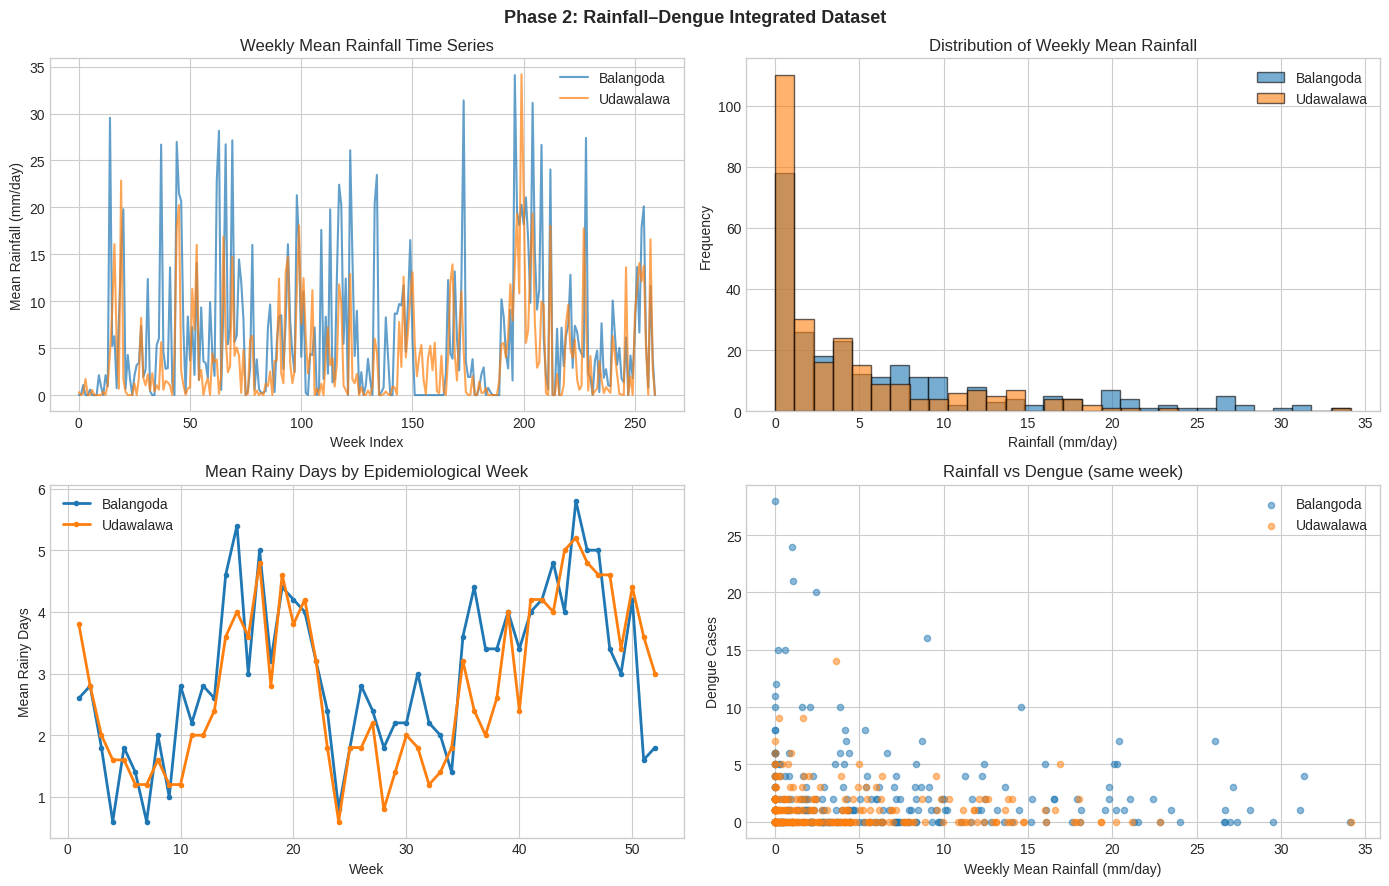

In [11]:
# Rainfall patterns visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Phase 2: Rainfall–Dengue Integrated Dataset', fontsize=13, fontweight='bold')

# Time series of mean rainfall
for moh in sorted(merged['MOH'].unique()):
    sub = merged[merged['MOH']==moh].reset_index(drop=True)
    axes[0,0].plot(range(len(sub)), sub['Weekly_Mean_Rainfall'], label=moh, alpha=0.7)
axes[0,0].set_title('Weekly Mean Rainfall Time Series')
axes[0,0].set_xlabel('Week Index'); axes[0,0].set_ylabel('Mean Rainfall (mm/day)')
axes[0,0].legend()

# Distribution
for moh in sorted(merged['MOH'].unique()):
    axes[0,1].hist(merged[merged['MOH']==moh]['Weekly_Mean_Rainfall'],
                   bins=30, alpha=0.6, label=moh, edgecolor='black')
axes[0,1].set_title('Distribution of Weekly Mean Rainfall')
axes[0,1].set_xlabel('Rainfall (mm/day)'); axes[0,1].set_ylabel('Frequency'); axes[0,1].legend()

# Rainy days by week
for moh in sorted(merged['MOH'].unique()):
    sub = merged[merged['MOH']==moh]
    axes[1,0].plot(sub.groupby('Week')['Rainy_Days'].mean().index,
                   sub.groupby('Week')['Rainy_Days'].mean().values,
                   label=moh, lw=2, marker='o', markersize=3)
axes[1,0].set_title('Mean Rainy Days by Epidemiological Week')
axes[1,0].set_xlabel('Week'); axes[1,0].set_ylabel('Mean Rainy Days'); axes[1,0].legend()

# Scatter: rainfall vs dengue
for moh in sorted(merged['MOH'].unique()):
    sub = merged[merged['MOH']==moh]
    axes[1,1].scatter(sub['Weekly_Mean_Rainfall'], sub['Dengue_Cases'],
                      alpha=0.5, s=20, label=moh)
axes[1,1].set_title('Rainfall vs Dengue (same week)')
axes[1,1].set_xlabel('Weekly Mean Rainfall (mm/day)')
axes[1,1].set_ylabel('Dengue Cases'); axes[1,1].legend()

plt.tight_layout()
plt.savefig('phase2_rainfall_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

## 2.10 Save Outputs

In [12]:
merged.to_csv('phase2_output_dengue_rainfall.csv', index=False)
print(f'Saved: phase2_output_dengue_rainfall.csv ({len(merged):,} records)')

for f in ['phase2_output_dengue_rainfall.csv', 'phase2_rainfall_patterns.png']:
    files.download(f)
    print(f'Downloaded: {f}')

Saved: phase2_output_dengue_rainfall.csv (520 records)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: phase2_output_dengue_rainfall.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: phase2_rainfall_patterns.png
